(400, 400) float32 0.0 1.0
(400, 400) bool False True 2
(400, 400) bool False True 2
(400, 400) float32 0.0 1.0 5


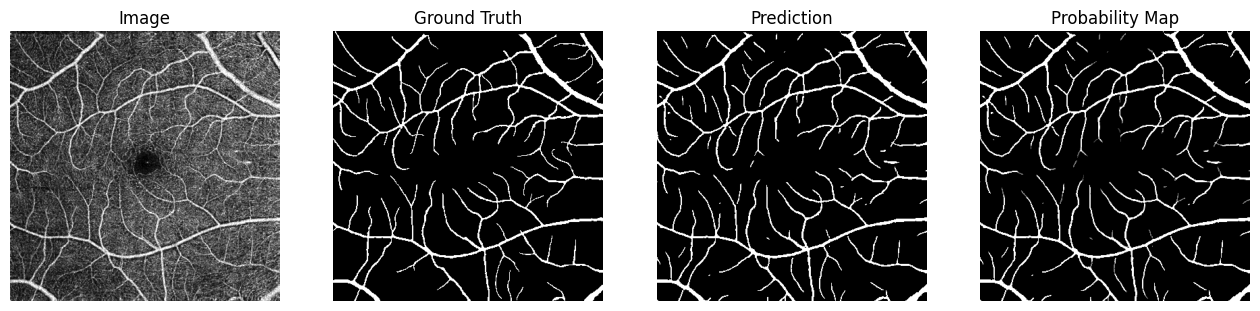

(400, 400) float32 0.0 1.0
(400, 400) bool False True 2
(400, 400) bool False True 2
(400, 400) float32 0.0 1.0 5


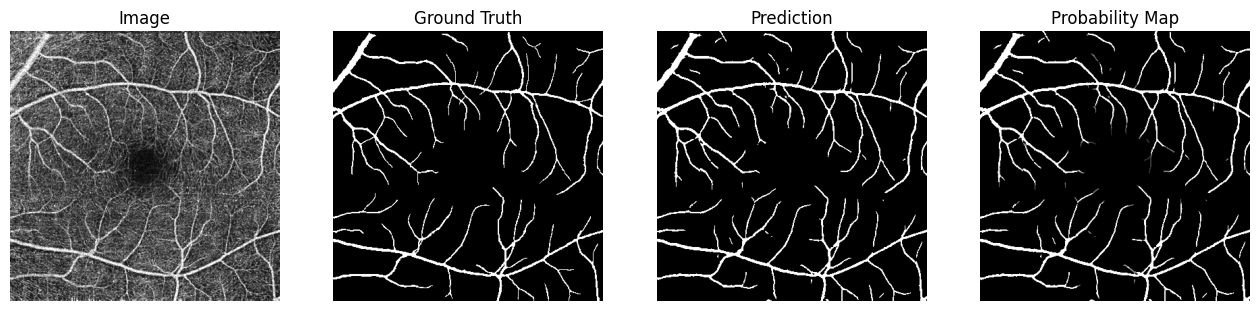

(400, 400) float32 0.0 1.0
(400, 400) bool False True 2
(400, 400) bool False True 2
(400, 400) float32 0.0 1.0 5


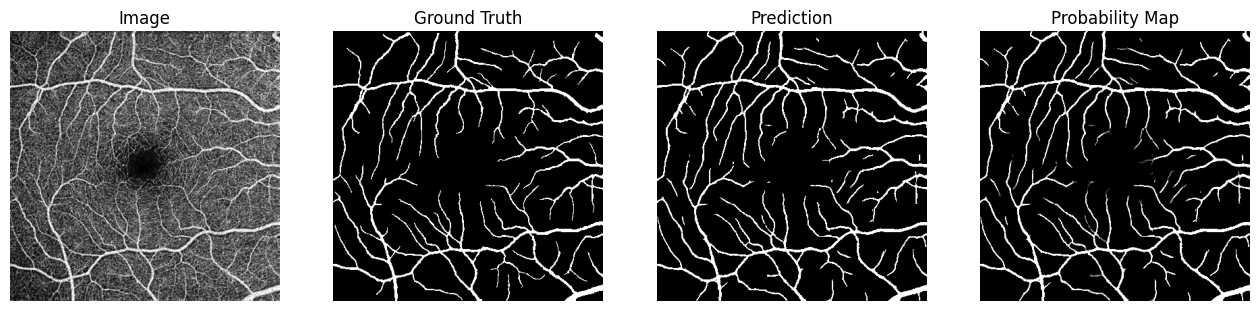

In [5]:
import os
import autorootcwd
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted

# img_dir = "outputs/JiT-B-16-OCTA500_6M/images-last"
dataset = "OCTA500_6M"
img_dir = f"outputs/JiT_ParaCond-B-16-{dataset}/images-10000"
images = natsorted([img for img in os.listdir(img_dir) if img.endswith('_image.npy')])
gts = natsorted([img for img in os.listdir(img_dir) if img.endswith('_gt.npy')])
preds = natsorted([img for img in os.listdir(img_dir) if img.endswith('_pred.npy')])
probs = natsorted([img for img in os.listdir(img_dir) if img.endswith('_prob.npy')])

for sample_idx, img in zip(range(0, 15, 5), images[:15:5]):
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 4, 1)
    image = np.load(os.path.join(img_dir, img))
    if image.shape[0] == 3:
        image = np.transpose(image, (1, 2, 0))
    print(image.shape, image.dtype, image.min(), image.max())
    plt.imshow(image, cmap='gray')
    plt.title('Image')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    gt = np.load(os.path.join(img_dir, gts[sample_idx]))
    print(gt.shape, gt.dtype, gt.min(), gt.max(), len(np.unique(gt)))
    plt.imshow(gt, cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    pred = np.load(os.path.join(img_dir, preds[sample_idx]))
    print(pred.shape, pred.dtype, pred.min(), pred.max(), len(np.unique(pred)))
    plt.imshow((pred > 0.5).astype(np.float32), cmap='gray')
    plt.title('Prediction')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    prob = np.load(os.path.join(img_dir, probs[sample_idx]))
    print(prob.shape, prob.dtype, prob.min(), prob.max(), len(np.unique(prob)))
    plt.imshow(prob, cmap='gray')
    plt.title('Probability Map')
    plt.axis('off')

    plt.show()

In [ ]:
import os
import autorootcwd
import matplotlib.pyplot as plt
import numpy as np
from src.engine_jit import calculate_metrics
from natsort import natsorted

img_dir = "outputs/JiT-B-16-OCTA500_6M/images-10000"
# img_dir = "outputs/JiT-H-32-OCTA500_6M/images-3000"
images = natsorted([img for img in os.listdir(img_dir) if img.endswith('_image.npy')])
gts = natsorted([img for img in os.listdir(img_dir) if img.endswith('_gt.npy')])
preds = natsorted([img for img in os.listdir(img_dir) if img.endswith('_pred.npy')])
probs = natsorted([img for img in os.listdir(img_dir) if img.endswith('_prob.npy')])
print(len(images), len(gts), len(preds), len(probs))

threshold = 0.5
# Dictionary to store all metrics
all_metrics = {}

for idx, (gt_file, pred_file) in enumerate(zip(gts, preds)):
    # Load images
    gt = np.load(os.path.join(img_dir, gt_file))
    pred = np.load(os.path.join(img_dir, pred_file))

    metrics = calculate_metrics(pred, gt, threshold=threshold)
    for metric_name, metric_value in metrics.items():
        if metric_name not in all_metrics:
            all_metrics[metric_name] = []
        all_metrics[metric_name].append(metric_value)

# Print all values and average
for metric_name, values in all_metrics.items():
    print(f"\n{metric_name} Average: {np.mean(values):.4f}")

In [ ]:
sample_indices = range(3)
fp_color = np.array([1.0, 0.4, 0.7])   # pink
fn_color = np.array([0.5, 0.8, 1.0])   # skyblue
alpha = 0.6
threshold = 0.5

for i in sample_indices:
    gt_img = np.load(os.path.join(img_dir, gts[i]))
    pred_img = np.load(os.path.join(img_dir, preds[i]))

    gt_bin = gt_img > threshold
    pred_bin = pred_img > threshold

    tp = pred_bin & gt_bin
    fp = pred_bin & ~gt_bin
    tn = ~pred_bin & ~gt_bin
    fn = ~pred_bin & gt_bin

    print(f"Sample {i}: TP {np.sum(tp)}, FP {np.sum(fp)}, TN {np.sum(tn)}, FN {np.sum(fn)}, Total {gt_bin.size}")
    print(f"GT: {np.sum(gt_bin)} positive, {gt_bin.size - np.sum(gt_bin)} negative")

    base = pred_img
    base_rgb = np.stack([base, base, base], axis=-1)

    overlay = base_rgb.copy() * 0.9
    overlay[fp] = (1 - alpha) * overlay[fp] + alpha * fp_color
    overlay[fn] = (1 - alpha) * overlay[fn] + alpha * fn_color

    plt.figure(figsize=(18, 5))
    plt.suptitle(f"F1: {all_metrics['dice'][i]:.4f}, IoU: {all_metrics['iou'][i]:.4f}")
    plt.subplot(1, 3, 1)
    plt.title("Ground Truth")
    plt.imshow(gt_img, cmap='gray')
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Prediction Overlay")
    plt.imshow(overlay)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(pred_img, cmap='gray')
    plt.axis("off")
    plt.show()

In [ ]:
%matplotlib inline
intermediates = os.listdir(img_dir + "/intermediates")
intermediates_000 = [f for f in intermediates if f.startswith('sample_000_intermediate_')]
intermediates_000 = natsorted(intermediates_000)
print(f"{len(intermediates_000)} samples")
plt.figure(figsize=(18,10))  # 10 x 5
for idx, int in enumerate(intermediates_000):
    plt.subplot(5, 10, idx + 1)
    step_idx = 50 - idx
    plt.title(f"Step {step_idx}")
    intermediate_img = np.load(os.path.join(img_dir, "intermediates", int))
    intermediate_img = (intermediate_img - intermediate_img.min()) / (intermediate_img.max() - intermediate_img.min())
    intermediate_img = (intermediate_img > 0.5).astype(np.float32)
    plt.imshow(intermediate_img, cmap='gray')
    plt.axis("off")
plt.show()

# Single file

In [ ]:
import autorootcwd
import os
import numpy as np
import matplotlib.pyplot as plt

data = plt.imread("data/OCTA500_6M/train/images/10001.bmp")
# data = np.load("outputs/JiT-L-16-OCTA500_6M/images-last/sample_000_gt.npy")
print(data.shape, data.dtype, data.min(), data.mean(), data.max(), len(np.unique(data)))

if data.ndim == 3 and data.shape[0] in (1, 3, 4):
    data = np.transpose(data, (1, 2, 0))
    if data.shape[2] == 1:
        data = data[..., 0]
# data = data[144:, 144:]


plt.figure(figsize=(6, 6), frameon=False)
plt.imshow(data, cmap='gray')
plt.axis('off')
plt.imsave("notebooks/sample.jpg", data, cmap='gray')

In [ ]:
import autorootcwd
import os
import numpy as np
import matplotlib.pyplot as plt

LargeVessel = plt.imread("data/Label/GT_LargeVessel/10001.bmp")
Artery = plt.imread("data/Label/GT_Artery/10001.bmp")
Vein = plt.imread("data/Label/GT_Vein/10001.bmp")
Capillary = plt.imread("data/Label/GT_Capillary/10001.bmp")
# data = np.load("outputs/JiT-L-16-OCTA500_6M/images-last/sample_000_gt.npy")
print(LargeVessel.shape, LargeVessel.dtype, LargeVessel.min(), LargeVessel.mean(), LargeVessel.max(), len(np.unique(LargeVessel)))
print(Artery.shape, Artery.dtype, Artery.min(), Artery.mean(), Artery.max(), len(np.unique(Artery)))
print(Vein.shape, Vein.dtype, Vein.min(), Vein.mean(), Vein.max(), len(np.unique(Vein)))
print(Capillary.shape, Capillary.dtype, Capillary.min(), Capillary.mean(), Capillary.max(), len(np.unique(Capillary)))

for data in [LargeVessel, Artery, Vein, Capillary]:
    if data.ndim == 3 and data.shape[0] in (1, 3, 4):
        data = np.transpose(data, (1, 2, 0))
        if data.shape[2] == 1:
            data = data[..., 0]
    data = data[144:, 144:]

plt.figure(figsize=(12, 4), frameon=False)
plt.subplot(1, 4, 1)
plt.imshow(LargeVessel, cmap='gray')
plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(Artery, cmap='gray')
plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(Vein, cmap='gray')
plt.axis('off')
plt.subplot(1, 4, 4)
plt.imshow(Capillary, cmap='gray')
plt.axis('off')
plt.imsave("notebooks/sample_all.jpg", LargeVessel, cmap='gray')
plt.show()